# Standard Kagome temperature-flow fRG pipeline

This notebook uses the **current uploaded source files directly**, without any extra stabilizer wrapper.

Pipeline:
1. Initialize the standard noninteracting kagome model  
   - `t=1`
   - no SOC / no flux: use `KagomeNagaosa(phi=0)`
   - filling = `5/12`
2. Build and visualize 24 FS patches
3. Build the bare extended Hubbard interaction with `U=8`, `V=0.2`
4. Build the kagome order diagnoser and show basic properties
5. Build the RG temperature flow and run **one step** with timing
6. Run the full flow until instability, then analyze the result

## Important note

This notebook assumes your current `frg_flow.py` already contains the updated
adaptive normalization using `effective_norm`.


In [1]:
import time
import importlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import noninteracting
import patching
import interaction
import kagome_order_diagnosis
import frg_flow
import frg_kernel

importlib.reload(noninteracting)
importlib.reload(patching)
importlib.reload(interaction)
importlib.reload(kagome_order_diagnosis)
importlib.reload(frg_kernel)
importlib.reload(frg_flow)

from noninteracting import KagomeNagaosa
from patching import FSPatcher, plot_patchset
from interaction import BareExtendedHubbard
from kagome_order_diagnosis import KagomeOrderDiagnoser
from frg_flow import FRGFlowSolver, BareVertexFromInteraction


## 1. Initialize the noninteracting model: standard kagome, filling `5/12`

In [2]:
model = KagomeNagaosa(parameters={"t": 1.0, "phi": 0.0}, spin=True, B=None)

filling = 5.0 / 12.0
mu = model.EF_from_filling(filling)

print("Model:", type(model).__name__)
print("parameters =", model.parameters)
print("spinful =", model.spin)
print("filling =", filling)
print("mu =", mu)
print("b1 =", model.b1)
print("b2 =", model.b2)


Model: KagomeNagaosa
parameters = {'t': 1.0, 'phi': 0.0}
spinful = True
filling = 0.4166666666666667
mu = -5.551115353402298e-17
b1 = [0.         3.62759873]
b2 = [3.14159265 1.81379936]


## 2. Build 24-patch FS patchsets for up / down and visualize

In [3]:
Npatch = 24
grid_size = 320

t0 = time.perf_counter()

patcher_up = FSPatcher(
    model,
    band_index=1,
    filling=filling,
    orbital_slice=slice(0, 3),
    Npatch=Npatch,
    grid_size=grid_size,
    gauge_fix="parallel_transport",
    close_loop_gauge=True,
    verbose=False,
)

patcher_dn = FSPatcher(
    model,
    band_index=1,
    filling=filling,
    orbital_slice=slice(3, 6),
    Npatch=Npatch,
    grid_size=grid_size,
    gauge_fix="parallel_transport",
    close_loop_gauge=True,
    verbose=False,
)

patchset_up = patcher_up.build()
patchset_dn = patcher_dn.build()

patchsets = {"up": patchset_up, "dn": patchset_dn}

patch_build_time = time.perf_counter() - t0

print(f"patch build time = {patch_build_time:.3f} s")
print("Npatch(up) =", patchset_up.Npatch)
print("Npatch(dn) =", patchset_dn.Npatch)
print("mu_used_for_contour =", patchset_up.mu_used_for_contour)
print("gauge_method =", patchset_up.gauge_method)
print("gauge_loop_phase =", patchset_up.gauge_loop_phase)


patch build time = 228.480 s
Npatch(up) = 24
Npatch(dn) = 24
mu_used_for_contour = 9.99999999999445e-05
gauge_method = parallel_transport
gauge_loop_phase = -1.2246467991473532e-16


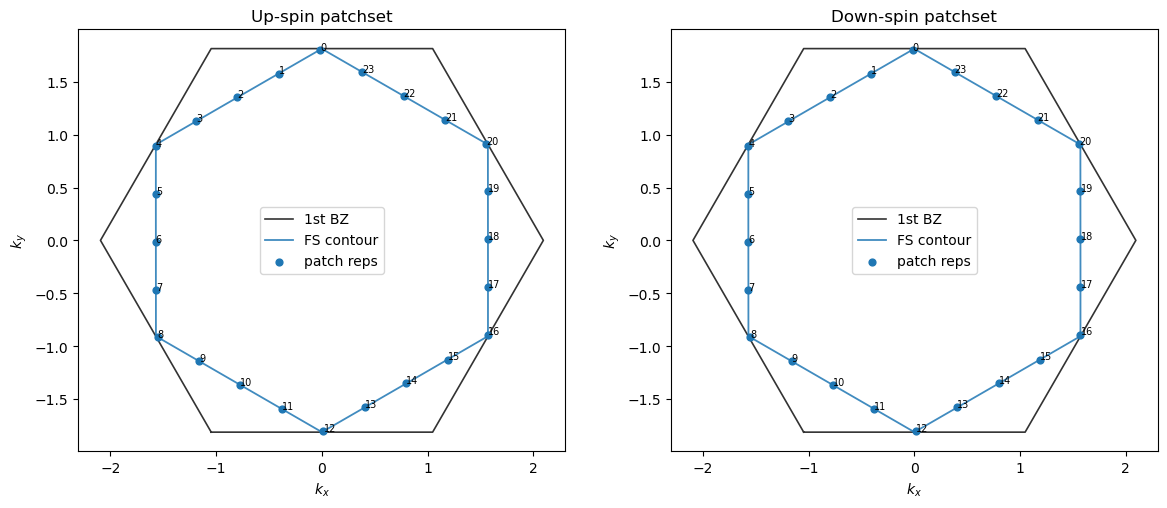

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

plot_patchset(patchset_up, ax=axes[0], show_contour=True, show_velocity=False, show_bz=True)
axes[0].set_title("Up-spin patchset")

plot_patchset(patchset_dn, ax=axes[1], show_contour=True, show_velocity=False, show_bz=True)
axes[1].set_title("Down-spin patchset")

plt.tight_layout()
plt.show()


## 3. Build the bare extended Hubbard interaction and show its properties

In [5]:
U = 8.0
V = 0.2

bare_int = BareExtendedHubbard.from_kagome_model(model, U=U, V=V)
gamma_bare = BareVertexFromInteraction(bare_int, patchsets)

print("interaction =", bare_int)
print("U =", bare_int.U)
print("V =", bare_int.V)
print("Norb =", bare_int.Norb)
print("delta1 =", bare_int.delta1)
print("delta2 =", bare_int.delta2)
print("delta3 =", bare_int.delta3)


interaction = BareExtendedHubbard(U=8.0, V=0.2, delta1=array([0.5      , 0.8660254]), delta2=array([ 0.5      , -0.8660254]), delta3=array([-1.,  0.]))
U = 8.0
V = 0.2
Norb = 3
delta1 = [0.5       0.8660254]
delta2 = [ 0.5       -0.8660254]
delta3 = [-1.  0.]


In [6]:
samples = [
    (0, "up", 0, "dn", 0, "up", 0, "dn"),
    (0, "up", 0, "up", 0, "up", 0, "up"),
    (0, "up", 0, "dn", 0, "up", 0, "up"),
]

print("Bare vertex samples:")
for args in samples:
    print(args, "->", gamma_bare(*args))

p1,p2,p3,p4 = 0,1,2,3
lhs = gamma_bare(p1,"up",p2,"dn",p3,"up",p4,"dn")
rhs = -gamma_bare(p1,"up",p2,"dn",p4,"dn",p3,"up")
print("\nAntisymmetry sample:")
print("lhs =", lhs)
print("rhs =", rhs)
print("residual =", lhs - rhs)


Bare vertex samples:
(0, 'up', 0, 'dn', 0, 'up', 0, 'dn') -> (7.99576100647654+0j)
(0, 'up', 0, 'up', 0, 'up', 0, 'up') -> 0j
(0, 'up', 0, 'dn', 0, 'up', 0, 'up') -> 0j

Antisymmetry sample:
lhs = (2.0300756126777473-2.4861256010929056e-16j)
rhs = (2.0300756126777473-2.4861256010929056e-16j)
residual = 0j


## 4. Build the order diagnoser and inspect its basic properties

In [7]:
diagnoser = KagomeOrderDiagnoser(patchsets_by_spin=patchsets)

print("Diagnoser =", type(diagnoser).__name__)
print("Npatch =", diagnoser.Npatch)
print("Norb =", diagnoser.Norb)
print("default_spin =", diagnoser.default_spin)
print("available spin sectors =", list(diagnoser.patchsets_by_spin.keys()))


Diagnoser = KagomeOrderDiagnoser
Npatch = 24
Norb = 3
default_spin = up
available spin sectors = ['up', 'dn']


In [8]:
diagnoser = KagomeOrderDiagnoser(patchsets_by_spin=patchsets)

print("Diagnoser =", type(diagnoser).__name__)
print("Npatch =", diagnoser.Npatch)
print("Norb =", diagnoser.Norb)
print("default_spin =", diagnoser.default_spin)
print("available spin sectors =", list(diagnoser.patchsets_by_spin.keys()))

Q0 = np.array([0.0, 0.0])

probe_solver = FRGFlowSolver(
    patchsets=patchsets,
    bare_gamma=gamma_bare,
    diagnoser=diagnoser,
    T_start=1.0,
    T_stop=0.5,
    n_steps=2,
    nfreq=8,
    diagnose_every=1,
    max_relative_update=1.0,
    min_substep_fraction=1.0/100000.0,
    diagnosis_Qs=[Q0],
)

diag0 = probe_solver.diagnose_current_state()
print("\nInitial diagnosis probe at Q=0 only:")
for k, v in diag0.items():
    print(f"{k}: {v}")

Diagnoser = KagomeOrderDiagnoser
Npatch = 24
Norb = 3
default_spin = up
available spin sectors = ['up', 'dn']

Initial diagnosis probe at Q=0 only:
channel_name: pp_singlet_sz0
Q: [0. 0.]
abs_eigenvalue: 127.99944382581218
order_label: unclassified
diagnosis: {'kernel': 'pp_singlet_sz0', 'Q': [0.0, 0.0], 'coarse_label': 'pp_even', 'coarse_score': 0.9999999990689772, 'paper_label': 'unclassified', 'paper_score': 0.0, 'recognition_status': 'novel_candidate', 'top_template_name': 'fSC_AC', 'top_template_score': 2.1510428829655758e-36, 'spin_sector': 'charge/singlet', 'channel_sector': 'pp', 'leg_spin_structure': ('up', 'dn'), 'degeneracy': 1, 'internal_mode': {'channel_sector': 'pp', 'spin_sector': 'charge/singlet', 'leg_spin_structure': ('up', 'dn'), 'tensor_basis_shape': (24, 3, 3, 1), 'dominant_pair': (1, 2), 'same_sublattice_weight': 6.73807758647444e-60, 'inter_sublattice_weight': 0.9999999999999999, 'pair_weights': [[3.5470381803513965e-61, 0.1665307316221363, 0.16522354950202647], 

## 5. Build the RG temperature flow and run one step with timing

In [10]:
solver = FRGFlowSolver(
    patchsets=patchsets,
    bare_gamma=gamma_bare,
    diagnoser=diagnoser,
    T_start=20.0,
    T_stop=0.05,
    n_steps=40,
    temperature_grid="log",
    nfreq=32,
    include_explicit_T_prefactor=True,
    diagnose_every=5,
    max_relative_update=1.0,
    min_substep_fraction=1.0/1000000.0,
    channel_divergence_threshold=50.0,
    eigenvalue_threshold=15.0,
)

print("Solver built.")
print("n_pp_Q =", len(solver.pp_grid.q_list))
print("n_ph_Q =", len(solver.phd_grid.q_list))
print("n_phc_Q =", len(solver.phc_grid.q_list))
print("temperature path head =", solver.temperature_path[:5])


Solver built.
n_pp_Q = 298
n_ph_Q = 541
n_phc_Q = 541
temperature path head = [20.         17.15183178 14.70926668 12.61454339 10.81812631]


In [ ]:
T_old = float(solver.temperature_path[0])
T_new = float(solver.temperature_path[1])
dT = T_new - T_old

print("One-step test:")
print("T_old =", T_old)
print("T_new =", T_new)
print("dT =", dT)

t0 = time.perf_counter()
rec1 = solver.step(T_old, dT)
step_time = time.perf_counter() - t0

print("\nOne-step record:")
print("temperature =", rec1.temperature)
print("rhs_norm =", rec1.rhs_norm)
print("channel_norm =", rec1.channel_norm)
print("accepted_substeps =", rec1.accepted_substeps)
print("max_rel_update =", rec1.max_rel_update)
print("step wall time (sec) =", step_time)


One-step test:
T_old = 20.0
T_new = 17.151831784058373
dT = -2.8481682159416266


## 6. Run the whole flow until instability, then analyze the result

In [ ]:
full_solver = FRGFlowSolver(
    patchsets=patchsets,
    bare_gamma=gamma_bare,
    diagnoser=diagnoser,
    T_start=20.0,
    T_stop=0.02,
    n_steps=60,
    temperature_grid="log",
    nfreq=32,
    include_explicit_T_prefactor=True,
    diagnose_every=1,
    max_relative_update=1.0,
    min_substep_fraction=1.0/1000000.0,
    channel_divergence_threshold=50.0,
    eigenvalue_threshold=15.0,
)

rows = []
temps = full_solver.temperature_path

# initial diagnosis
t_init = time.perf_counter()
initial = full_solver.diagnose_current_state()
t_init = time.perf_counter() - t_init

rows.append({
    "step_index": 0,
    "temperature": float(temps[0]),
    "dT": 0.0,
    "rhs_norm": 0.0,
    "channel_norm": float(full_solver.state.channel_norm()),
    "accepted_substeps": 0,
    "max_rel_update": 0.0,
    "leading_channel_name": initial.get("channel_name"),
    "leading_eigenvalue_abs": initial.get("abs_eigenvalue"),
    "leading_order_label": initial.get("order_label"),
    "instability": False,
    "instability_reason": None,
    "rhs_time_sec": 0.0,
    "diag_time_sec": t_init,
    "step_total_time_sec": t_init,
})

instability_rec = None

for i in range(len(temps) - 1):
    T_old = float(temps[i])
    T_new = float(temps[i + 1])
    dT = T_new - T_old

    t_step0 = time.perf_counter()
    rec = full_solver.step(T_old, dT)
    step_time = time.perf_counter() - t_step0

    t_diag0 = time.perf_counter()
    payload = full_solver.diagnose_current_state()
    diag_time = time.perf_counter() - t_diag0

    rec.leading_channel_name = payload.get("channel_name")
    rec.leading_Q = payload.get("Q")
    rec.leading_eigenvalue_abs = payload.get("abs_eigenvalue")
    rec.leading_order_label = payload.get("order_label")
    rec.diagnosis_payload = payload.get("diagnosis") or {}

    rec.instability, rec.instability_reason = full_solver.check_instability(rec)

    rows.append({
        "step_index": int(rec.step_index),
        "temperature": float(rec.temperature),
        "dT": float(rec.dT),
        "rhs_norm": float(rec.rhs_norm),
        "channel_norm": float(rec.channel_norm),
        "accepted_substeps": int(rec.accepted_substeps),
        "max_rel_update": float(rec.max_rel_update),
        "leading_channel_name": rec.leading_channel_name,
        "leading_eigenvalue_abs": rec.leading_eigenvalue_abs,
        "leading_order_label": rec.leading_order_label,
        "instability": bool(rec.instability),
        "instability_reason": rec.instability_reason,
        "rhs_time_sec": step_time,
        "diag_time_sec": diag_time,
        "step_total_time_sec": step_time + diag_time,
    })

    if rec.instability:
        instability_rec = rec
        break

hist_df = pd.DataFrame(rows)
display(hist_df)

if instability_rec is not None:
    print("\nStopped by instability:")
    print(instability_rec.instability_reason)
else:
    print("\nNo explicit instability threshold hit before T_stop.")


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(hist_df["temperature"], hist_df["channel_norm"], marker="o")
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_xlabel("T")
axes[0].set_ylabel("channel_norm")
axes[0].set_title("Channel norm vs T")

axes[1].plot(hist_df["temperature"], hist_df["leading_eigenvalue_abs"], marker="o")
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_xlabel("T")
axes[1].set_ylabel("leading |eigenvalue|")
axes[1].set_title("Leading eigenvalue vs T")

axes[2].plot(hist_df["step_index"], hist_df["step_total_time_sec"], marker="o", label="total")
axes[2].plot(hist_df["step_index"], hist_df["rhs_time_sec"], marker="o", label="step")
axes[2].plot(hist_df["step_index"], hist_df["diag_time_sec"], marker="o", label="diag")
axes[2].set_xlabel("step index")
axes[2].set_ylabel("time (sec)")
axes[2].set_title("Per-step timing")
axes[2].legend()

plt.tight_layout()
plt.show()


In [ ]:
final_row = hist_df.iloc[-1]
print("Final row summary:")
display(final_row.to_frame())

print("\nExpectation from PRL in this regime: FM.")
print("Check whether the final / stopping leading_order_label tends to FM and whether the strongest Q is near zero.")


## Interpretation

For this parameter choice (`U=8`, `V=0.2`, filling `5/12`), the PRL expectation is FM-like behavior:

- strongest particle-hole spin-like tendency
- \(Q \approx 0\)
- diagnosis leaning toward `FM`

If the run does not show FM immediately, the first knobs to tune are:

- `nfreq`
- `n_steps`
- patch number
- stopping thresholds

before changing model physics.
